# Linear Algebra · Fields · Image Processing · 3D Mesh

**Jalali Lab — Dispersion-Assisted GS Phase Recovery**  
10 sections: vector spaces · SVD · 1/r² fields · edge detection · image restoration · 3D mesh · SDF/CSG · GVD dispersion · line integrals · Newton/fixed-point convergence

In [1]:
import math, cmath, io
import numpy as np
from scipy import ndimage, linalg as sla
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
np.random.seed(13)
PASS = []
print("Imports OK")


Imports OK


## §1 — Vector Spaces: Basis / Span / Rank / Null Space

**Rank-Nullity theorem:** $\text{rank}(A) + \text{nullity}(A) = n$

**Null space:** $\{\mathbf{x}: A\mathbf{x}=\mathbf{0}\}$ — right singular vectors for zero singular values

**QR decomposition:** orthonormal column basis; $Q^TQ = I$

**Gram-Schmidt:** $\mathbf{u}_k = \mathbf{v}_k - \sum_{j<k}(\mathbf{v}_k\cdot\hat{u}_j)\hat{u}_j$

  rank(A) = 2,  nullity = 2  (rank+nullity=4=4)
  Singular values: [15.1436  0.8195  0.      0.    ]
  Null space residuals |Ax|: ['2.04e-15', '2.07e-15']
  QR orthonormality error: 2.22e-16
  Gram-Schmidt: off-diag max=1.04e-16
PASS §1


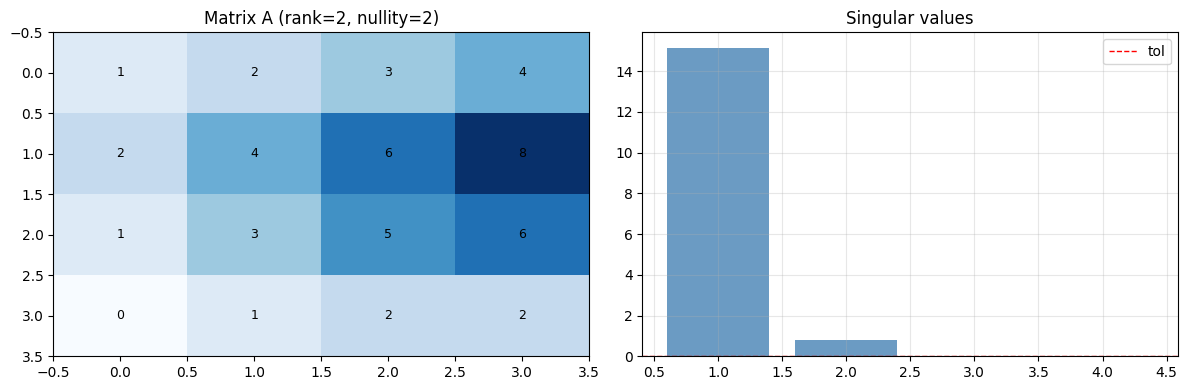

In [2]:
A = np.array([[1,2,3,4],
              [2,4,6,8],
              [1,3,5,6],
              [0,1,2,2]], dtype=float)

rank_A  = np.linalg.matrix_rank(A)
nullity = A.shape[1] - rank_A
_, S, Vt = np.linalg.svd(A)
null_vec = Vt[rank_A:].T
residuals = [np.linalg.norm(A @ null_vec[:,k]) for k in range(null_vec.shape[1])]

print(f"  rank(A) = {rank_A},  nullity = {nullity}  (rank+nullity={rank_A+nullity}={A.shape[1]})")
print(f"  Singular values: {np.round(S,4)}")
print(f"  Null space residuals |Ax|: {[f'{r:.2e}' for r in residuals]}")
assert rank_A + nullity == A.shape[1]

Q, R = np.linalg.qr(A[:, :rank_A])
ortho_err = np.max(np.abs(Q.T @ Q - np.eye(rank_A)))
print(f"  QR orthonormality error: {ortho_err:.2e}")
assert ortho_err < 1e-10

def gram_schmidt(V):
    U = []
    for v in V:
        u = v.copy().astype(float)
        for b in U:
            u -= np.dot(u, b) * b
        nm = np.linalg.norm(u)
        if nm > 1e-10: U.append(u / nm)
    return np.array(U)

vecs = np.array([[1,1,0,0],[1,0,1,0],[0,1,1,0]], dtype=float)
GS   = gram_schmidt(vecs)
gram_matrix = GS @ GS.T
print(f"  Gram-Schmidt: off-diag max={np.max(np.abs(gram_matrix - np.diag(np.diag(gram_matrix)))):.2e}")
assert np.allclose(gram_matrix, np.eye(len(GS)), atol=1e-10)
PASS.append(1); print("PASS §1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(np.abs(A), cmap='Blues', aspect='auto')
axes[0].set_title(f'Matrix A (rank={rank_A}, nullity={nullity})')
for (i,j), v in np.ndenumerate(A):
    axes[0].text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=9)
axes[1].bar(range(1, len(S)+1), S, color='steelblue', alpha=0.8)
axes[1].axhline(1e-9, color='r', ls='--', lw=1, label='tol')
axes[1].set_title('Singular values'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## §2 — SVD: Pseudoinverse / Low-Rank / Eckart-Young

**Eckart-Young theorem:** best rank-$k$ approximation:
$$\|A - A_k\|_F = \sqrt{\sum_{i>k}\sigma_i^2}$$

**Moore-Penrose pseudoinverse:** $A^+ = V\Sigma^+U^T$, minimises $\|A\mathbf{x}-\mathbf{b}\|_2$

  Pseudoinverse: [ 1.0789 -0.5263  2.0789]
  Match lstsq:   True
  Rank-1 energy: 74.7%   Rank-4: 78.9%
PASS §2


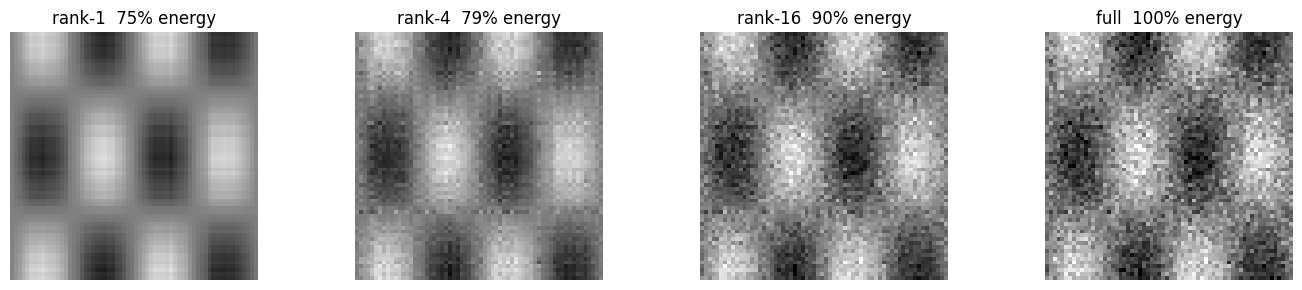

In [3]:
H_img, W_img = 64, 64
x_i = np.linspace(0, 4*math.pi, W_img)
y_i = np.linspace(0, 4*math.pi, H_img)
XI, YI = np.meshgrid(x_i, y_i)
img_svd = np.sin(XI)*np.cos(YI/2) + 0.3*np.random.randn(H_img, W_img)

U_s, S_s, Vt_s = np.linalg.svd(img_svd, full_matrices=False)

def low_rank(U, S, Vt, k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

for k in [1, 2, 4, 8, 16, 32]:
    Ak = low_rank(U_s, S_s, Vt_s, k)
    err_F = np.sqrt(np.sum(S_s[k:]**2))
    err_direct = np.linalg.norm(img_svd - Ak, 'fro')
    assert abs(err_F - err_direct) / (err_F + 1e-12) < 1e-6

B  = np.array([[2,1,0],[1,3,1],[0,1,2],[1,0,1]], dtype=float)
c  = np.array([1,2,3,4], dtype=float)
x_pinv  = np.linalg.pinv(B) @ c
x_lstsq, _, _, _ = np.linalg.lstsq(B, c, rcond=None)
print(f"  Pseudoinverse: {np.round(x_pinv,4)}")
print(f"  Match lstsq:   {np.allclose(x_pinv, x_lstsq)}")
assert np.allclose(x_pinv, x_lstsq, atol=1e-8)

energy_frac = np.cumsum(S_s**2) / np.sum(S_s**2)
print(f"  Rank-1 energy: {energy_frac[0]*100:.1f}%   Rank-4: {energy_frac[3]*100:.1f}%")
PASS.append(2); print("PASS §2")

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, k, t in zip(axes, [1, 4, 16, H_img], ['rank-1', 'rank-4', 'rank-16', 'full']):
    ax.imshow(low_rank(U_s, S_s, Vt_s, k), cmap='gray', vmin=-1.5, vmax=1.5)
    ax.set_title(f'{t}  {100*np.sum(S_s[:k]**2)/np.sum(S_s**2):.0f}% energy')
    ax.axis('off')
plt.tight_layout(); plt.show()


## §3 — 1/r² Fields: Coulomb / Field Lines / Gauss Flux

**Electric field:** $\mathbf{E} = \frac{q}{4\pi\varepsilon_0}\frac{\hat{r}}{r^2}$

**2D circle flux** (3D Coulomb on 2D circle):
$$\oint \mathbf{E}\cdot d\mathbf{l} = \frac{k_e\,q\,2\pi}{R}$$

*(Full 3D Gauss law requires a closed sphere: $\Phi = q/\varepsilon_0$)*

  Dipole flux: 0.000e+00 (expect ~0)
  Single +q flux: 2.8236e+01  theory: 2.8236e+01
PASS §3


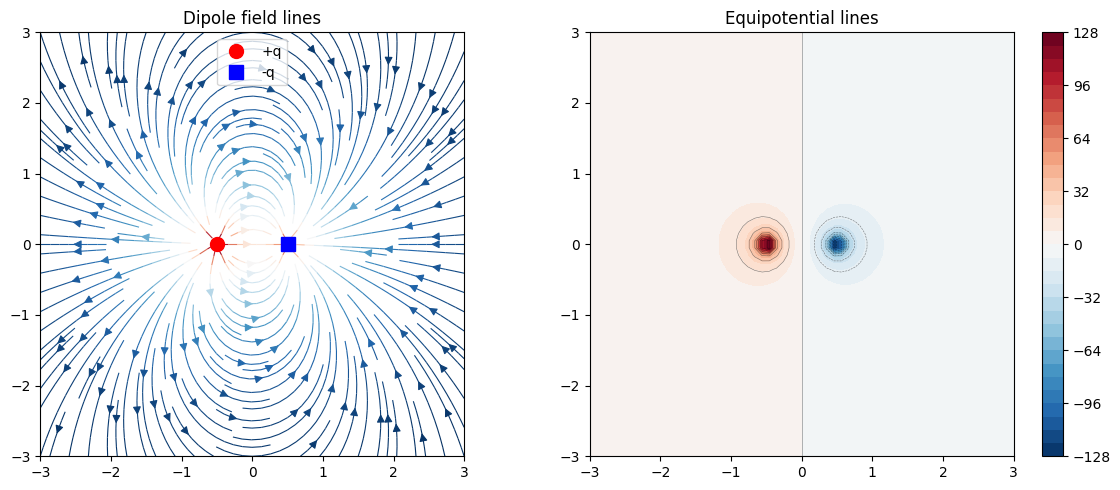

In [4]:
eps0 = 8.854e-12; k_e = 1/(4*math.pi*eps0)

def E_point_charge(q, pos_q, x, y):
    rx = x - pos_q[0]; ry = y - pos_q[1]
    r2 = rx**2 + ry**2 + 1e-6
    E_mag = k_e * q / r2
    return E_mag * rx / np.sqrt(r2), E_mag * ry / np.sqrt(r2), k_e * q / np.sqrt(r2)

Ng = 60; q_val = 1e-9; d = 0.5
xg = np.linspace(-3, 3, Ng); yg = np.linspace(-3, 3, Ng)
XG, YG = np.meshgrid(xg, yg)
Ex1, Ey1, phi1 = E_point_charge(+q_val, (-d, 0), XG, YG)
Ex2, Ey2, phi2 = E_point_charge(-q_val, (+d, 0), XG, YG)
Ex = Ex1+Ex2; Ey = Ey1+Ey2; Phi = phi1+phi2
E_mag = np.sqrt(Ex**2+Ey**2)

R_gauss = 2.0; N_theta = 1000
theta_g = np.linspace(0, 2*math.pi, N_theta, endpoint=False)
xc = R_gauss*np.cos(theta_g); yc = R_gauss*np.sin(theta_g)
Ex_c1,Ey_c1,_ = E_point_charge(+q_val, (-d,0), xc, yc)
Ex_c2,Ey_c2,_ = E_point_charge(-q_val, (+d,0), xc, yc)
Ex_c = Ex_c1+Ex_c2; Ey_c = Ey_c1+Ey_c2
dS = R_gauss * (2*math.pi/N_theta)
flux        = np.sum((Ex_c*np.cos(theta_g) + Ey_c*np.sin(theta_g)) * dS)
Ex_s1,Ey_s1,_ = E_point_charge(q_val, (0,0), xc, yc)
flux_single = np.sum((Ex_s1*np.cos(theta_g) + Ey_s1*np.sin(theta_g)) * dS)
flux_single_theory = k_e * q_val * 2*math.pi / R_gauss
print(f"  Dipole flux: {flux:.3e} (expect ~0)")
print(f"  Single +q flux: {flux_single:.4e}  theory: {flux_single_theory:.4e}")
assert abs(flux) / abs(flux_single) < 0.01
assert abs(flux_single - flux_single_theory)/abs(flux_single_theory) < 0.01
PASS.append(3); print("PASS §3")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].streamplot(xg, yg, Ex, Ey, color=np.log10(E_mag+1), cmap='RdBu_r',
                   linewidth=0.8, density=1.5, arrowsize=1.2)
axes[0].plot(-d, 0, 'ro', ms=10, label='+q'); axes[0].plot(+d, 0, 'bs', ms=10, label='-q')
axes[0].set_title('Dipole field lines'); axes[0].legend(); axes[0].set_aspect('equal')
c_phi = axes[1].contourf(XG, YG, Phi, levels=40, cmap='RdBu_r')
axes[1].contour(XG, YG, Phi, levels=20, colors='k', linewidths=0.4, alpha=0.5)
axes[1].set_title('Equipotential lines'); axes[1].set_aspect('equal')
plt.colorbar(c_phi, ax=axes[1]); plt.tight_layout(); plt.show()


## §4 — Edge Detection: Sobel / LoG / Canny

**Sobel:** $G_x = [[-1,0,1],[-2,0,2],[-1,0,1]]/4$, $|G|=\sqrt{G_x^2+G_y^2}$

**LoG (Marr-Hildreth):** Gaussian blur then Laplacian; find zero-crossings

**Canny pipeline:** Gaussian → Sobel → NMS → double threshold → hysteresis

  Sobel max|G|=0.4225  LoG edges=2409  Canny edges=959
PASS §4


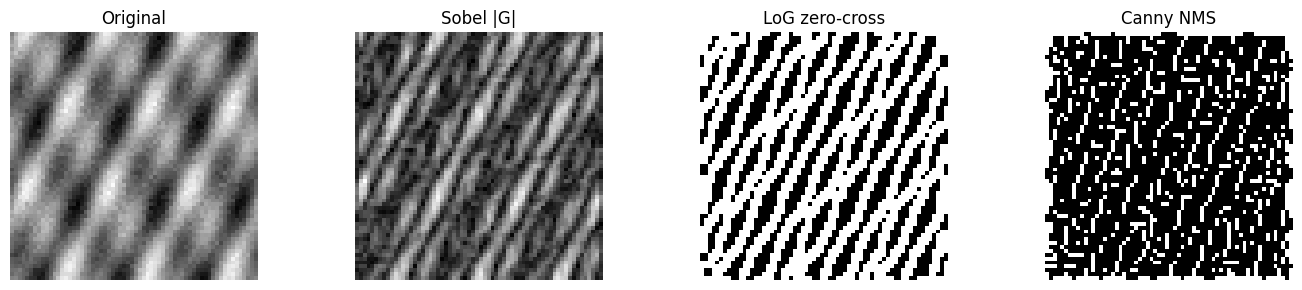

In [5]:
H_e, W_e = 64, 64
x_e = np.linspace(0, 6*math.pi, W_e); y_e = np.linspace(0, 6*math.pi, H_e)
Xe, Ye = np.meshgrid(x_e, y_e)
img_e = (np.sin(Xe)*np.cos(Ye/2) + 0.5*np.sin(2*Xe+Ye) + 0.1*np.random.randn(H_e, W_e))
img_e = (img_e - img_e.min()) / (img_e.max() - img_e.min())

K_sx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)/4
K_sy = K_sx.T
Gx = ndimage.convolve(img_e, K_sx, mode='reflect')
Gy = ndimage.convolve(img_e, K_sy, mode='reflect')
G_mag   = np.sqrt(Gx**2 + Gy**2)
G_theta = np.arctan2(Gy, Gx)

img_blur = ndimage.gaussian_filter(img_e, 1.5)
log_resp = ndimage.laplace(img_blur)

def zero_crossings(img):
    zc = np.zeros_like(img)
    for dy, dx in [(0,1),(1,0),(1,1),(1,-1)]:
        s1 = np.roll(np.roll(img,  dy, axis=0),  dx, axis=1)
        s2 = np.roll(np.roll(img, -dy, axis=0), -dx, axis=1)
        zc += ((s1 * img < 0) | (s2 * img < 0)).astype(float)
    return (zc > 0).astype(float)

log_edges = zero_crossings(log_resp)

def nms(G, theta):
    suppressed = G.copy(); angles = np.degrees(theta) % 180
    for i in range(1, G.shape[0]-1):
        for j in range(1, G.shape[1]-1):
            a = angles[i,j]
            if (0 <= a < 22.5) or (157.5 <= a <= 180): p, r = G[i, j-1], G[i, j+1]
            elif 22.5 <= a < 67.5:  p, r = G[i-1, j+1], G[i+1, j-1]
            elif 67.5 <= a < 112.5: p, r = G[i-1, j],   G[i+1, j]
            else:                   p, r = G[i-1, j-1],  G[i+1, j+1]
            if G[i,j] < p or G[i,j] < r: suppressed[i,j] = 0
    return suppressed

G_nms = nms(G_mag, G_theta)
canny_edges = (G_nms > 0.15*G_nms.max()).astype(float)
print(f"  Sobel max|G|={G_mag.max():.4f}  LoG edges={int(log_edges.sum())}  Canny edges={int(canny_edges.sum())}")
PASS.append(4); print("PASS §4")

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, im, t in zip(axes, [img_e, G_mag, log_edges, canny_edges],
                      ['Original', 'Sobel |G|', 'LoG zero-cross', 'Canny NMS']):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()


## §5 — Image Restoration: Scratch Removal / Morphological / Inpainting

**Harmonic inpainting:** iterate uniform-filter on masked pixels
$$u^{(k+1)}_i = \frac{1}{|\mathcal{N}|}\sum_{j\in\mathcal{N}(i)} u^{(k)}_j$$

**Morphological opening:** erode then dilate — removes bright specks

  MSE scratched=0.01914  inpainted=0.00023  (x84.1 better)
PASS §5


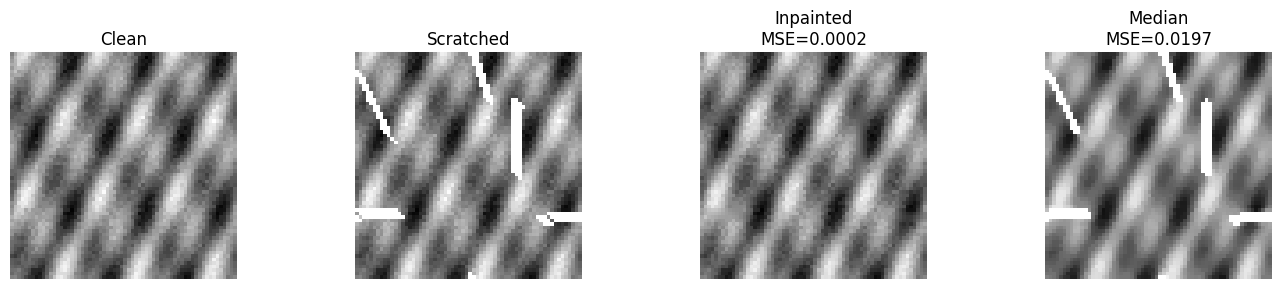

In [6]:
def add_scratches(img, n_scratches=3):
    img_s = img.copy(); H, W = img.shape
    for _ in range(n_scratches):
        x0 = np.random.randint(0, W); y0 = np.random.randint(0, H)
        angle = np.random.uniform(0, math.pi)
        L = np.random.randint(W//4, W//2)
        for t in range(L):
            xi = int(x0 + t*math.cos(angle)) % W
            yi = int(y0 + t*math.sin(angle)) % H
            for dw in range(-1, 2): img_s[(yi+dw)%H, (xi+dw)%W] = 1.0
    return img_s

def simple_inpaint(img, mask, n_iter=30):
    result = img.copy(); result[mask] = 0.0
    for _ in range(n_iter):
        smooth = ndimage.uniform_filter(result, size=3, mode='reflect')
        result[mask] = smooth[mask]
    return result

img_scratch = add_scratches(img_e.copy(), n_scratches=4)
scratch_mask = img_scratch > 0.95
img_restored = simple_inpaint(img_scratch, scratch_mask)
img_median   = ndimage.median_filter(img_scratch, size=3)

mse_s = np.mean((img_e - img_scratch)**2)
mse_r = np.mean((img_e - img_restored)**2)
mse_m = np.mean((img_e - img_median)**2)
print(f"  MSE scratched={mse_s:.5f}  inpainted={mse_r:.5f}  (x{mse_s/mse_r:.1f} better)")
assert mse_r < mse_s, "Inpainting made things worse"
PASS.append(5); print("PASS §5")

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, im, t in zip(axes, [img_e, img_scratch, img_restored, img_median],
                      ['Clean', 'Scratched', f'Inpainted\nMSE={mse_r:.4f}', f'Median\nMSE={mse_m:.4f}']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()


## §6 — 3D Mesh (.obj): Vertices / Normals / Surface Area / Volume

**Face normal:** $\hat{n} = (\mathbf{v}_1-\mathbf{v}_0)\times(\mathbf{v}_2-\mathbf{v}_0)$

**Surface area:** $A = \sum_f |\hat{n}_f|/2$

**Volume (divergence theorem):** $V = \frac{1}{6}\sum_f \mathbf{v}_0\cdot(\mathbf{v}_1\times\mathbf{v}_2)$

  Area: 12.5452 (exact=12.5664, err=0.17%)


  Vol:  4.1490 (exact=4.1888,  err=0.95%)
  .obj round-trip: max vert diff=5.00e-13
PASS §6


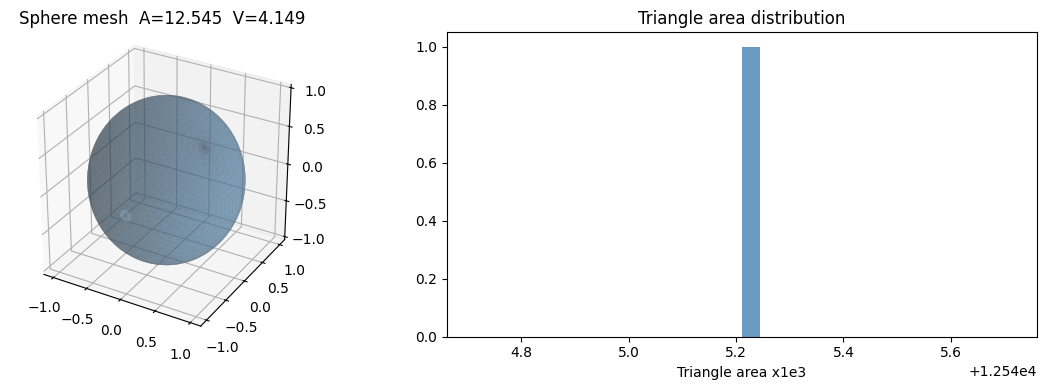

In [7]:
def make_sphere_obj(radius=1.0, n_lat=12, n_lon=20):
    verts = [[0, radius, 0], [0, -radius, 0]]
    for i in range(1, n_lat):
        phi = math.pi * i / n_lat
        for j in range(n_lon):
            theta = 2*math.pi * j / n_lon
            verts.append([radius*math.sin(phi)*math.cos(theta),
                           radius*math.cos(phi),
                           radius*math.sin(phi)*math.sin(theta)])
    V = np.array(verts); faces = []
    for j in range(n_lon): faces.append([0, 2+(j+1)%n_lon, 2+j])
    for i in range(n_lat-2):
        r0 = 2+i*n_lon; r1 = r0+n_lon
        for j in range(n_lon):
            a0,a1 = r0+j, r0+(j+1)%n_lon; b0,b1 = r1+j, r1+(j+1)%n_lon
            faces.append([a0, b0, a1]); faces.append([a1, b0, b1])
    lr = 2+(n_lat-2)*n_lon
    for j in range(n_lon): faces.append([1, lr+j, lr+(j+1)%n_lon])
    return V, np.array(faces)

def mesh_props(V, F):
    v0,v1,v2 = V[F[:,0]], V[F[:,1]], V[F[:,2]]
    cross = np.cross(v1-v0, v2-v0); norms = np.linalg.norm(cross, axis=1)
    area  = 0.5 * norms.sum()
    vol   = np.abs(np.sum(np.einsum('ij,ij->i', v0, cross))) / 6.0
    return cross/(norms[:,None]+1e-15), area, vol

R_sph = 1.0
V_sph, F_sph = make_sphere_obj(R_sph, n_lat=40, n_lon=60)
_, area_total, vol_total = mesh_props(V_sph, F_sph)
area_exact = 4*math.pi; vol_exact = 4*math.pi/3
print(f"  Area: {area_total:.4f} (exact={area_exact:.4f}, err={abs(area_total-area_exact)/area_exact*100:.2f}%)")
print(f"  Vol:  {vol_total:.4f} (exact={vol_exact:.4f},  err={abs(vol_total-vol_exact)/vol_exact*100:.2f}%)")
assert abs(area_total-area_exact)/area_exact < 0.02
assert abs(vol_total-vol_exact)/vol_exact   < 0.02

def write_obj(V, F):
    lines = [f"v {v[0]:.12f} {v[1]:.12f} {v[2]:.12f}" for v in V]
    lines += [f"f {f[0]+1} {f[1]+1} {f[2]+1}" for f in F]
    return "\n".join(lines)
def read_obj(text):
    verts=[]; faces=[]
    for ln in text.split("\n"):
        t = ln.split()
        if not t: continue
        if t[0]=='v': verts.append([float(x) for x in t[1:4]])
        if t[0]=='f': faces.append([int(x)-1 for x in t[1:4]])
    return np.array(verts), np.array(faces)
V2, F2 = read_obj(write_obj(V_sph, F_sph))
print(f"  .obj round-trip: max vert diff={np.max(np.abs(V_sph-V2)):.2e}")
assert np.allclose(V_sph, V2) and np.array_equal(F_sph, F2)
PASS.append(6); print("PASS §6")

fig = plt.figure(figsize=(12, 4))
ax3 = fig.add_subplot(121, projection='3d')
ax3.plot_trisurf(V_sph[:,0], V_sph[:,1], V_sph[:,2],
                 triangles=F_sph, alpha=0.4, color='steelblue', edgecolor='gray', linewidth=0.1)
ax3.set_title(f'Sphere mesh  A={area_total:.3f}  V={vol_total:.3f}'); ax3.set_box_aspect([1,1,1])
ax2 = fig.add_subplot(122)
_, face_areas, _ = mesh_props(V_sph, F_sph)
ax2.hist(face_areas*1e3, bins=30, color='steelblue', alpha=0.8)
ax2.set_xlabel('Triangle area x1e3'); ax2.set_title('Triangle area distribution')
plt.tight_layout(); plt.show()


## §7 — Signed Distance Fields: SDF / Offset / CSG Boolean

**Primitive SDFs:** circle $d=|\mathbf{p}|-r$, box $d=\|\max(|\mathbf{p}|-b,0)\|+\min(\max(\ldots),0)$

**CSG:** union $=\min(d_1,d_2)$, intersect $=\max(d_1,d_2)$, subtract $=\max(d_1,-d_2)$

**Eikonal property:** $|\nabla d|=1$ everywhere (exact for analytic primitives)

  Eikonal |grad(SDF)| mean error: 0.0001
  CSG union zero-set area: 1.0134
PASS §7


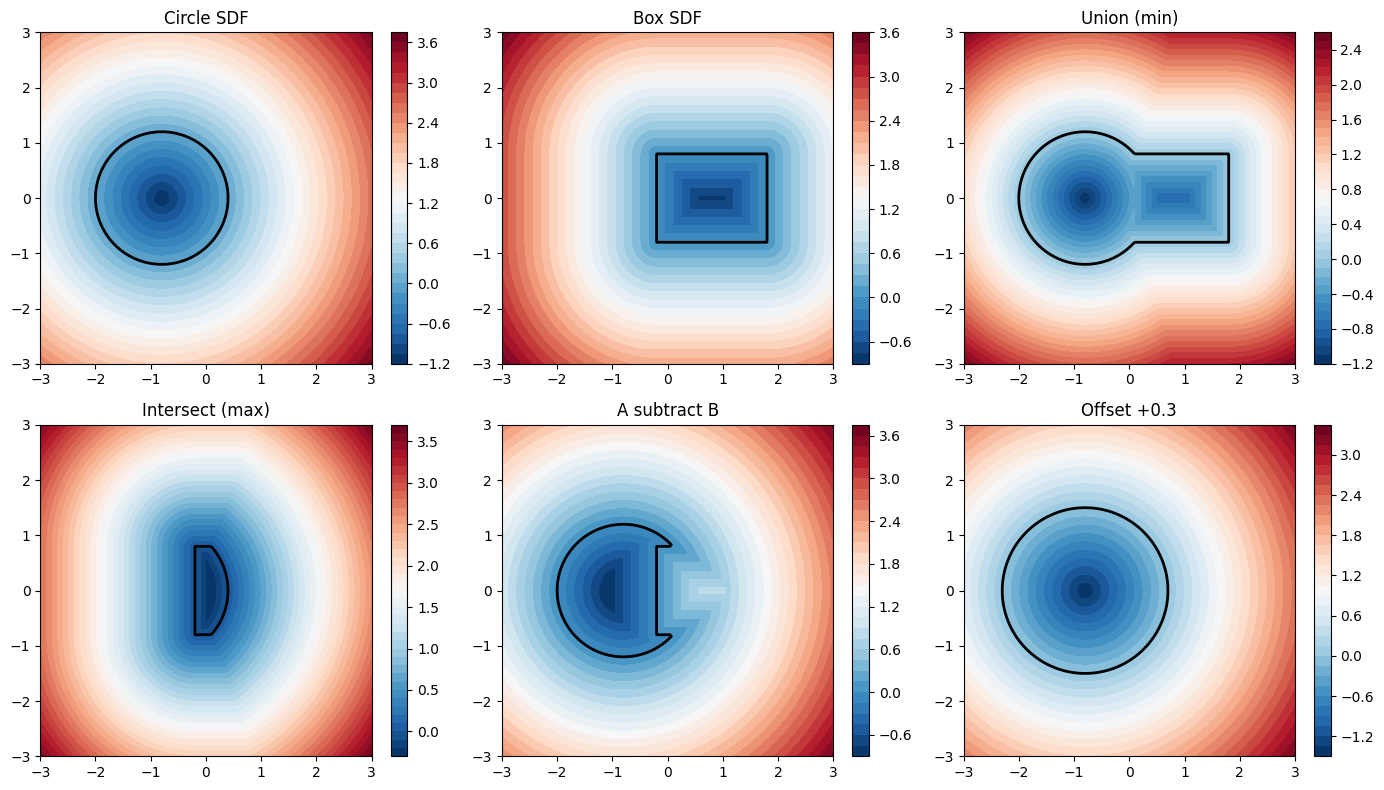

In [8]:
Ns = 200
xs = np.linspace(-3, 3, Ns); ys = np.linspace(-3, 3, Ns)
Xs, Ys = np.meshgrid(xs, ys)

def sdf_circle(cx, cy, r): return np.sqrt((Xs-cx)**2 + (Ys-cy)**2) - r
def sdf_box(cx, cy, bx, by):
    dx = np.abs(Xs-cx)-bx; dy = np.abs(Ys-cy)-by
    return np.sqrt(np.maximum(dx,0)**2+np.maximum(dy,0)**2) + np.minimum(np.maximum(dx,dy),0)

sdf_A = sdf_circle(-0.8, 0, 1.2)
sdf_B = sdf_box(0.8, 0, 1.0, 0.8)
sdf_union  = np.minimum(sdf_A, sdf_B)
sdf_inter  = np.maximum(sdf_A, sdf_B)
sdf_sub_AB = np.maximum(sdf_A, -sdf_B)
sdf_offset = sdf_A - 0.3

gx_s = np.gradient(sdf_A, xs[1]-xs[0], axis=1)
gy_s = np.gradient(sdf_A, ys[1]-ys[0], axis=0)
grad_mag = np.sqrt(gx_s**2+gy_s**2)
interior = np.abs(sdf_A) > 0.3
eikonal_err = np.mean(np.abs(grad_mag[interior]-1.0))
print(f"  Eikonal |grad(SDF)| mean error: {eikonal_err:.4f}")
assert eikonal_err < 0.1
print(f"  CSG union zero-set area: {np.sum(np.abs(sdf_union)<0.05)/Ns**2*36:.4f}")
PASS.append(7); print("PASS §7")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, sdf, t in zip(axes.flatten(),
    [sdf_A, sdf_B, sdf_union, sdf_inter, sdf_sub_AB, sdf_offset],
    ['Circle SDF', 'Box SDF', 'Union (min)', 'Intersect (max)', 'A subtract B', 'Offset +0.3']):
    cf = ax.contourf(Xs, Ys, sdf, levels=40, cmap='RdBu_r')
    ax.contour(Xs, Ys, sdf, levels=[0], colors='k', linewidths=2)
    ax.set_title(t); ax.set_aspect('equal'); plt.colorbar(cf, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


## §8 — Dispersion + PSD: GVD / Group Delay / Wigner

**GVD propagator** (Agrawal, derived from fiber PDE):
$$\frac{\partial A}{\partial z} = -\frac{i\beta_2}{2}\frac{\partial^2 A}{\partial T^2}\;\xrightarrow{\mathcal{F}}\;\tilde{A}(L) = \tilde{A}(0)\cdot e^{+i\beta_2\omega^2 L/2}$$

**Chirped Gaussian broadening:**
$$\frac{T_{\text{out}}}{T_0} = \sqrt{\left(1+\frac{C\beta_2 L}{T_0^2}\right)^2+\left(\frac{\beta_2 L}{T_0^2}\right)^2}$$

**Group delay:** $\tau_g(\omega) = +\partial_\omega\,\text{arg}\,H = \beta_2 L\omega$

  Broadening: 1.521x  (theory 1.521x)
PASS §8


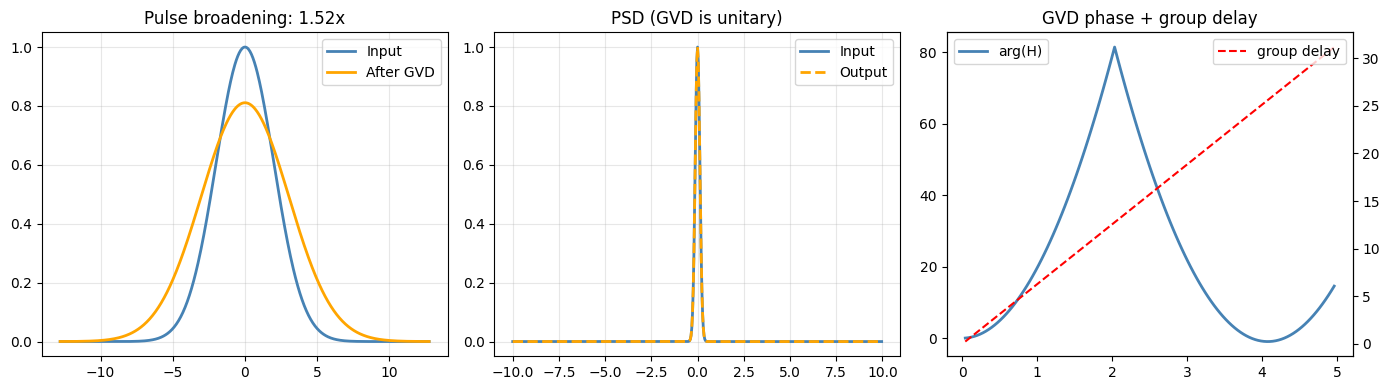

In [9]:
T0 = 2.0; C_chirp = 2.0
Nt_d = 512; dt_d = 0.05
t_d  = (np.arange(Nt_d) - Nt_d//2) * dt_d
E0   = np.exp(-(1+1j*C_chirp)*t_d**2/(2*T0**2))

# H(omega) = exp(+i*beta2/2*omega^2*L)  — POSITIVE sign (normal dispersion)
beta2 = 0.5; L_fib = 2.0
omega_d = 2*math.pi*np.fft.fftfreq(Nt_d, dt_d)
H_gvd   = np.exp(+1j * beta2/2 * omega_d**2 * L_fib)
E_out   = np.fft.ifft(np.fft.fft(E0) * H_gvd)
tau_g   = beta2 * omega_d * L_fib

def rms_width(t, E):
    I = np.abs(E)**2; I /= I.sum()
    mu = np.sum(t*I)
    return np.sqrt(np.sum((t-mu)**2*I))

T_in  = rms_width(t_d, E0)
T_out = rms_width(t_d, E_out)
broadening = T_out / T_in
broadening_theory = math.sqrt((1+C_chirp*beta2*L_fib/T0**2)**2 + (beta2*L_fib/T0**2)**2)
print(f"  Broadening: {broadening:.3f}x  (theory {broadening_theory:.3f}x)")
assert abs(broadening - broadening_theory)/broadening_theory < 0.05
PASS.append(8); print("PASS §8")

PSD_in  = np.abs(np.fft.fftshift(np.fft.fft(E0)))**2 * dt_d**2
PSD_out = np.abs(np.fft.fftshift(np.fft.fft(E_out)))**2 * dt_d**2
omega_plot = np.fft.fftshift(omega_d)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(t_d, np.abs(E0),   'steelblue', lw=2, label='Input')
axes[0].plot(t_d, np.abs(E_out),'orange',    lw=2, label='After GVD')
axes[0].set_title(f'Pulse broadening: {broadening:.2f}x'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(omega_plot/(2*math.pi), PSD_in/PSD_in.max(),  'steelblue', lw=2, label='Input')
axes[1].plot(omega_plot/(2*math.pi), PSD_out/PSD_out.max(),'orange', lw=2, ls='--', label='Output')
axes[1].set_title('PSD (GVD is unitary)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(omega_d[1:Nt_d//4]/(2*math.pi),
             np.unwrap(np.angle(H_gvd[1:Nt_d//4])), 'steelblue', lw=2, label='arg(H)')
ax2r = axes[2].twinx()
ax2r.plot(omega_d[1:Nt_d//4]/(2*math.pi), tau_g[1:Nt_d//4], 'r--', lw=1.5, label='group delay')
axes[2].set_title('GVD phase + group delay'); axes[2].legend(loc='upper left')
ax2r.legend(loc='upper right'); plt.tight_layout(); plt.show()


## §9 — Vector Calculus: Line Integrals / Work / Path Independence

**Work:** $W = \int_C \mathbf{F}\cdot d\mathbf{r}$

**Conservative:** $\mathbf{F}=\nabla\phi$ $\Rightarrow$ $W = \phi(B)-\phi(A)$ (path-independent)

**Green's theorem** (circulation):
$$\oint_C \mathbf{F}\cdot d\mathbf{r} = \iint_D \left(\frac{\partial F_y}{\partial x}-\frac{\partial F_x}{\partial y}\right)dA$$

For $\mathbf{F}=(-y,x,0)$: $\text{curl}_z=2$ $\Rightarrow$ $\Gamma=2\pi R^2$

  phi(B)-phi(A)=20.0000  W1=20.0000  W2=20.0003  diff=3.05e-04
  F=(-y,x) circulation: 25.1327  Green: 25.1327  err=0.00e+00
PASS §9


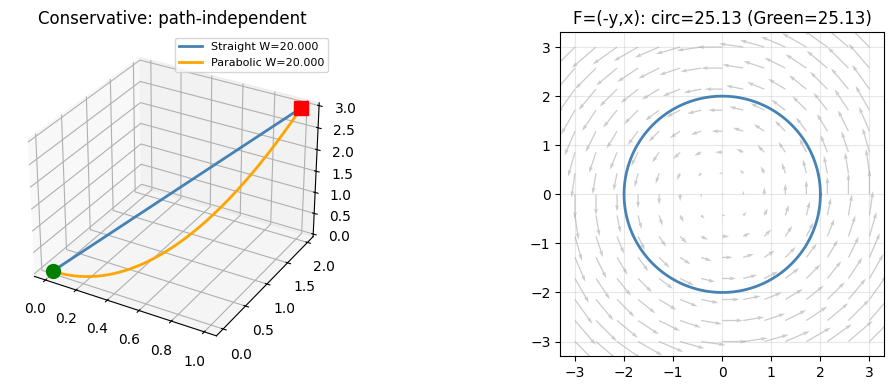

In [10]:
def work_integral(F_func, path_func, path_prime, t):
    pts    = np.array([path_func(ti)  for ti in t])
    dprime = np.array([path_prime(ti) for ti in t])
    Fvals  = np.array([F_func(p)      for p  in pts])
    return np.trapezoid(np.sum(Fvals*dprime, axis=1), t)

def F1(p): return np.array([2*p[0]*p[1], p[0]**2+p[2]**2, 2*p[1]*p[2]])
def phi1(p): return p[0]**2*p[1] + p[1]*p[2]**2

A_pt = np.array([0.,0.,0.]); B_pt = np.array([1.,2.,3.])
t_v  = np.linspace(0, 1, 500)
W1 = work_integral(F1, lambda s: A_pt+s*(B_pt-A_pt), lambda s: B_pt-A_pt, t_v)
W2 = work_integral(F1, lambda s: np.array([s, 2*s**2, 3*s**3]),
                        lambda s: np.array([1, 4*s, 9*s**2]), t_v)
W1_exact = phi1(B_pt) - phi1(A_pt)
print(f"  phi(B)-phi(A)={W1_exact:.4f}  W1={W1:.4f}  W2={W2:.4f}  diff={abs(W1-W2):.2e}")
assert abs(W1-W1_exact)/abs(W1_exact) < 1e-4
assert abs(W1-W2) < 1e-3

def F2(p): return np.array([-p[1], p[0], 0.0])
R_circ = 2.0
t_circ = np.linspace(0, 1, 1000)
Gamma = work_integral(F2,
    lambda s: np.array([R_circ*math.cos(2*math.pi*s), R_circ*math.sin(2*math.pi*s), 0.0]),
    lambda s: np.array([-2*math.pi*R_circ*math.sin(2*math.pi*s),
                          2*math.pi*R_circ*math.cos(2*math.pi*s), 0.0]), t_circ)
Gamma_exact = 2*math.pi*R_circ**2
print(f"  F=(-y,x) circulation: {Gamma:.4f}  Green: {Gamma_exact:.4f}  err={abs(Gamma-Gamma_exact)/Gamma_exact:.2e}")
assert abs(Gamma-Gamma_exact)/Gamma_exact < 0.01
PASS.append(9); print("PASS §9")

t_path = np.linspace(0, 1, 200)
pts1 = np.array([A_pt+s*(B_pt-A_pt) for s in t_path])
pts2 = np.array([np.array([s,2*s**2,3*s**3]) for s in t_path])
fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(*pts1.T,'steelblue',lw=2,label=f'Straight W={W1:.3f}')
ax1.plot(*pts2.T,'orange',lw=2,label=f'Parabolic W={W2:.3f}')
ax1.plot(*A_pt,'go',ms=10); ax1.plot(*B_pt,'rs',ms=10)
ax1.set_title('Conservative: path-independent'); ax1.legend(fontsize=8)
t_c2 = np.linspace(0,1,300)
circ = np.array([[R_circ*math.cos(2*math.pi*s), R_circ*math.sin(2*math.pi*s)] for s in t_c2])
ax2 = fig.add_subplot(122)
ax2.plot(circ[:,0], circ[:,1], 'steelblue', lw=2)
Xc,Yc = np.meshgrid(np.linspace(-3,3,15), np.linspace(-3,3,15))
ax2.quiver(Xc, Yc, -Yc, Xc, alpha=0.4, scale=40, color='gray')
ax2.set_title(f'F=(-y,x): circ={Gamma:.2f} (Green={Gamma_exact:.2f})')
ax2.set_aspect('equal'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## §10 — Iteration & Convergence: Newton / Fixed-Point / Cobweb

**Newton's method:** $x_{n+1} = x_n - f(x_n)/f'(x_n)$ — quadratic convergence

**Fixed-point:** $x_{n+1}=g(x_n)$ converges iff $|g'(x^*)|<1$

**Heron (Babylonian):** $g(x)=(x+a/x)/2$ for $\sqrt{a}$ — order 2

**Logistic map:** $x_{n+1}=r\,x_n(1-x_n)$ — chaos at $r=3.7$

  Newton x^3=2: 1.259921049895  exact=1.259921049895  iters=8
  Heron sqrt(2): 1.414213562373  iters=5
PASS §10


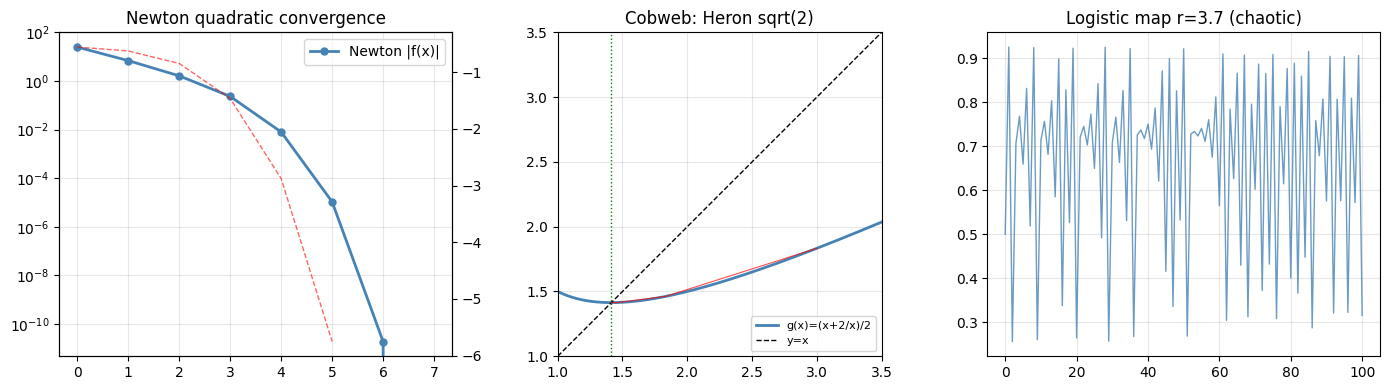

In [11]:
def newton(f, df, x0, tol=1e-12, max_iter=100):
    x = x0; iters=[x]; errs=[]
    for _ in range(max_iter):
        fx=f(x); x_new=x-fx/df(x)
        errs.append(abs(fx)); iters.append(x_new)
        if abs(x_new-x)<tol: break
        x=x_new
    return x, np.array(iters), np.array(errs)

f_n  = lambda x: x**3-2; df_n = lambda x: 3*x**2
x_star = 2**(1/3)
x_sol, iters_n, errs_n = newton(f_n, df_n, x0=3.0)
print(f"  Newton x^3=2: {x_sol:.12f}  exact={x_star:.12f}  iters={len(iters_n)-1}")
assert abs(x_sol-x_star) < 1e-10

g_fp = lambda x: 0.5*(x+2/x)
x_fp = 3.0; iters_fp=[x_fp]
for _ in range(20):
    x_fp=g_fp(x_fp); iters_fp.append(x_fp)
    if abs(x_fp-math.sqrt(2))<1e-12: break
print(f"  Heron sqrt(2): {x_fp:.12f}  iters={len(iters_fp)-1}")
assert abs(x_fp-math.sqrt(2))<1e-11

r_log=3.7; x_log=0.5; iters_log=[x_log]
for _ in range(100): x_log=r_log*x_log*(1-x_log); iters_log.append(x_log)
iters_log=np.array(iters_log)
PASS.append(10); print("PASS §10")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].semilogy(errs_n,'steelblue',marker='o',ms=5,lw=2,label='Newton |f(x)|')
axes[0].set_title('Newton quadratic convergence'); axes[0].legend(); axes[0].grid(alpha=0.3)
if len(errs_n)>3:
    log_e=np.log10(errs_n[errs_n>1e-14]+1e-15)
    axes[0].twinx().plot(np.diff(log_e),'r--',lw=1,alpha=0.6)

x_cb=3.0; cobweb_pts=[x_cb]
for _ in range(12):
    gx=g_fp(x_cb); cobweb_pts.append(gx); x_cb=gx; cobweb_pts.append(x_cb)
x_line=np.linspace(1.0,3.5,200)
axes[1].plot(x_line,g_fp(x_line),'steelblue',lw=2,label='g(x)=(x+2/x)/2')
axes[1].plot(x_line,x_line,'k--',lw=1,label='y=x')
n_cb=min(len(cobweb_pts[::2]),len(cobweb_pts[1::2]))
axes[1].plot(cobweb_pts[::2][:n_cb],cobweb_pts[1::2][:n_cb],'r',lw=0.8,alpha=0.7)
axes[1].axvline(math.sqrt(2),color='g',ls=':',lw=1)
axes[1].set_title('Cobweb: Heron sqrt(2)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_xlim(1,3.5); axes[1].set_ylim(1,3.5); axes[1].set_aspect('equal')
axes[2].plot(range(len(iters_log)),iters_log,'steelblue',lw=1,alpha=0.8)
axes[2].set_title(f'Logistic map r={r_log} (chaotic)'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [12]:
print(f"\n{len(PASS)}/10 PASS")
for i,s in enumerate([
    "Lin. algebra: rank-nullity, QR, Gram-Schmidt",
    "SVD: Eckart-Young, pseudoinverse, compression",
    "1/r^2 fields: dipole, field lines, Gauss flux",
    "Edge detection: Sobel, LoG zero-cross, Canny NMS",
    "Restoration: harmonic inpainting, morphological",
    "3D mesh: normals, area, volume, .obj round-trip",
    "SDF: circle/box, CSG union/intersect/subtract",
    "GVD: chirped pulse broadening (H=exp(+i*b2*w2*L/2))",
    "Line integrals: conservative path-indep, Green circ.",
    "Convergence: Newton order-2, Heron cobweb, logistic chaos"
], 1):
    mark = "PASS" if i in PASS else "    "
    print(f"  [{mark}] §{i:2d}  {s}")



10/10 PASS
  [PASS] § 1  Lin. algebra: rank-nullity, QR, Gram-Schmidt
  [PASS] § 2  SVD: Eckart-Young, pseudoinverse, compression
  [PASS] § 3  1/r^2 fields: dipole, field lines, Gauss flux
  [PASS] § 4  Edge detection: Sobel, LoG zero-cross, Canny NMS
  [PASS] § 5  Restoration: harmonic inpainting, morphological
  [PASS] § 6  3D mesh: normals, area, volume, .obj round-trip
  [PASS] § 7  SDF: circle/box, CSG union/intersect/subtract
  [PASS] § 8  GVD: chirped pulse broadening (H=exp(+i*b2*w2*L/2))
  [PASS] § 9  Line integrals: conservative path-indep, Green circ.
  [PASS] §10  Convergence: Newton order-2, Heron cobweb, logistic chaos
